# Dimensiones de la red multicapa

Nodos y enlaces de las tres capas, disponibilidad de datos por especie y
distribución de grado de las afiliaciones. Son las cifras que se citan en el
texto (Tables 1–3 del paper 2019 y S1 Fig del 2016).

Fuente: `analiceDB/01_tablas_analisis.ipynb` de v3 + `reproducir_v6/descriptivos_red/`.

Independiente del barrido: se puede correr en cualquier momento (README §6.4).
Salidas: `01_dimensiones_capas.csv`, `01_disponibilidad_especie.csv`,
`01_grado_afiliaciones.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/analiceDB")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_analice as fa              # el .py de esta carpeta

SALIDAS = tdr.out("analiceDB")
FIGURAS = SALIDAS / "figuras"
NB      = "01"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out')

## Datos

In [2]:
# cluster_consistent=False: acá se describe la base entera, sin filtrar nada.
datos = tdr.cargar_db(anotaciones=True, fenotipo=True, cluster_consistent=False)
datos.st.shape, datos.bioact.shape, datos.sta.shape

· 00_specie_target
· 03_bioactivities_target_compound
· 04a_interpro / 04b_orthomcl
· 03_bioactivities_organism_compound


((399353, 3), (3526999, 6), (769661, 4))

## Acondicionamiento

In [3]:
spoi = datos.especies_con_druggables(minimo=10)
resumen_tablas = pd.DataFrame({
    "tabla": ["00_specie_target", "03_bioactivities_target_compound",
              "03_bioactivities_organism_compound", "04a+04b (sta)"],
    "filas": [len(datos.st), len(datos.bioact), len(datos.bioact_org), len(datos.sta)],
})
print(f"{len(spoi)} especies con más de 10 druggables")
resumen_tablas

16 especies con más de 10 druggables


,tabla,filas
0,00_specie_target,399353
1,03_bioactivities_target_compound,3526999
2,03_bioactivities_organism_compound,931971
3,04a+04b (sta),769661


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
dim  = fa.dimensiones_capas(datos)
disp = fa.disponibilidad_por_especie(datos)
grad = fa.grado_afiliaciones(datos)

dim.to_csv(SALIDAS / f"{NB}_dimensiones_capas.csv", index=False)
disp.to_csv(SALIDAS / f"{NB}_disponibilidad_especie.csv", index=False)
grad.to_csv(SALIDAS / f"{NB}_grado_afiliaciones.csv", index=False)
fa.escribir_meta(SALIDAS, NB, notebook="01_dimensiones_red.ipynb",
                 params={"cluster_consistent": False, "con_quimica": False}, especies=spoi)

  meta -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/01_meta.json


{'notebook': '01_dimensiones_red.ipynb',
 'nb': '01',
 'fecha': '2026-09-07 09:06',
 'params': {'cluster_consistent': False, 'con_quimica': False},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_clusters_subestructure.csv': '2026-05-13',
  '03_bioactivities_organism_compound.csv': '2026-06-04',
  '03_bioactivities_target_compound.csv': '2026-08-07',
  '04a_interpro.csv': '2026-06-10',
  '04b_orthomcl.csv': '2026-08-25'},
 'python': '3.12.2',
 'pandas': '2.2.3',
 'especies': ['hsap',
  'ecol',
  'scer',
  'mmus',
  'atha',
  'mtub',
  'dmel',
  'pfal',
  'tbrt',
  'cele',
  'calb',
  'osat',
  'lmaj',
  'tcr',
  'sao',
  'ddis']}

# Resultados

In [5]:
dim  = pd.read_csv(SALIDAS / f"{NB}_dimensiones_capas.csv")
disp = pd.read_csv(SALIDAS / f"{NB}_disponibilidad_especie.csv")
grad = pd.read_csv(SALIDAS / f"{NB}_grado_afiliaciones.csv")
dim

,capa,entidad,n
0,2 - proteínas,proteínas (V_P),399352
1,2 - proteínas,especies,30
2,3 - afiliaciones,categorías InterPro,14083
3,3 - afiliaciones,categorías OrthoMCL,76157
4,2-3 (afiliación),enlaces proteína-categoría,769661
5,1-2 (bioactividad),registros compuesto-proteína,3526999
6,1-2 (bioactividad),enlaces E_DP positivos,248545
7,1-2 (bioactividad),enlaces E_DP negativos,144552
8,1-2 (bioactividad),proteínas druggables,19650
9,1 - compuestos,compuestos con bioactividad,949054


In [6]:
disp[disp["sp_id"].isin(tdr.ESPECIES_16)][
    ["sp_id", "nombre", "grupo", "proteinas", "con_interpro", "con_orthomcl",
     "pct_interpro", "pct_orthomcl", "druggables"]].round(1)

,sp_id,nombre,grupo,proteinas,con_interpro,con_orthomcl,pct_interpro,pct_orthomcl,druggables
1,hsap,Homo sapiens,Mamíferos,18052,11799,16301.0,65.4,90.3,1985
2,ecol,Escherichia coli,Bacterias,4598,2795,4529.0,60.8,98.5,752
3,scer,Saccharomyces cerevisiae,Hongos,6743,3463,6091.0,51.4,90.3,533
4,mmus,Mus musculus,Mamíferos,18683,13362,18185.0,71.5,97.3,402
5,atha,Arabidopsis thaliana,Plantas,21747,15694,21712.0,72.2,99.8,362
6,mtub,Mycobacterium tuberculosis,Bacterias,4083,2559,4073.0,62.7,99.8,204
7,dmel,Drosophila melanogaster,Invertebrados,10707,7495,10693.0,70.0,99.9,123
8,pfal,Plasmodium falciparum,Protozoos,5495,2457,5495.0,44.7,100.0,95
9,tbrt,Trypanosoma brucei,Protozoos,8832,3562,8632.0,40.3,97.7,68
10,cele,Caenorhabditis elegans,Invertebrados,27512,14168,27425.0,51.5,99.7,63


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/01_f01_disponibilidad.pdf


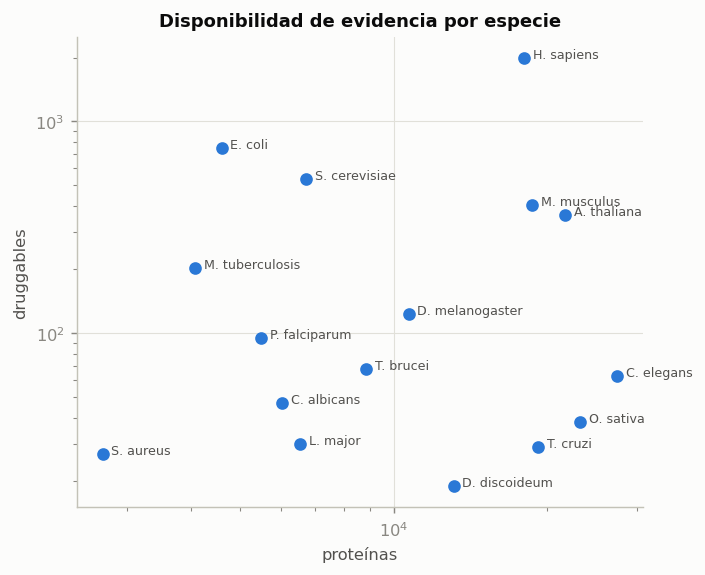

In [7]:
fig = fa.fig_disponibilidad(disp, plt)
tdr.guardar(fig, f"{NB}_f01_disponibilidad", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/01_f02_grado_afiliaciones.pdf


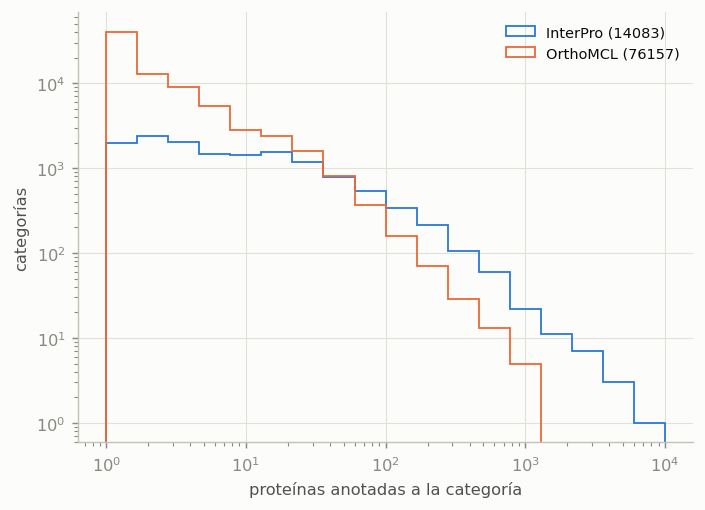

In [11]:
# Cola pesada: las categorías grandes son las que beta > 0 (G'rk) atenúa
fig = fa.fig_grado(grad, plt)
tdr.guardar(fig, f"{NB}_f02_grado_afiliaciones", FIGURAS)

In [20]:
t

db,ip,omcl,inicio
tramo,,,
1,1950,40428,1
>1000,33,3,1000
101-1000,724,266,101
2-5,5020,25154,2
21-100,2642,2969,21
6-20,3714,7337,6


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/01_f03_tramos_de_grado.pdf


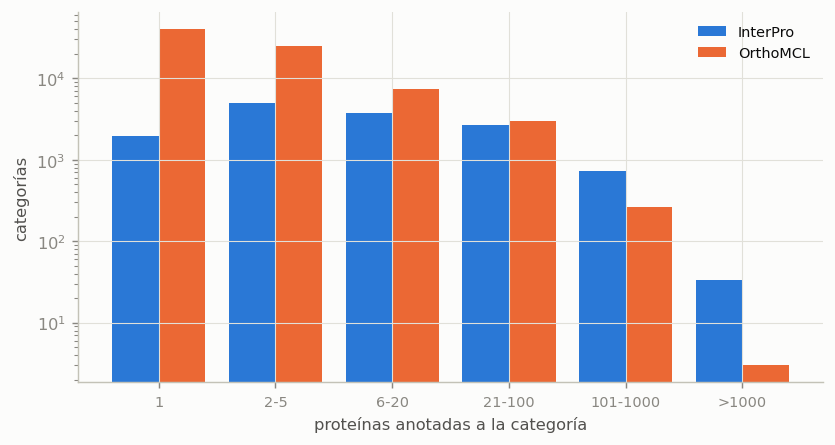

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 3.5), tight_layout=True)
t = grad.groupby(["tramo", "db"], observed=True).size().unstack(fill_value=0)
t['inicio'] = t.index
t['inicio'] = t['inicio'].apply(lambda x: x.split('-')[0].lstrip(">")).astype(int)
t.sort_values('inicio', inplace=True)
x = np.arange(len(t))
ax.bar(x - 0.2, t.get("ip", 0), width=0.4, color=tdr.S1, label="InterPro")
ax.bar(x + 0.2, t.get("omcl", 0), width=0.4, color=tdr.S2, label="OrthoMCL")
ax.set_xticks(x); ax.set_xticklabels(t.index, fontsize=8)
ax.set_yscale("log")
ax.set_xlabel("proteínas anotadas a la categoría")
ax.set_ylabel("categorías")
ax.legend(fontsize=8)
tdr.guardar(fig, f"{NB}_f03_tramos_de_grado", FIGURAS)